# Phân Tích Khám Phá Dữ Liệu (EDA)
## Dữ liệu bán hàng xe đạp — Giai đoạn 2025-01 đến 2026-02

Notebook này khám phá toàn bộ bộ dữ liệu bán hàng: doanh thu theo tháng, theo nhóm sản phẩm, theo đại lý, phân tích mùa vụ và kiểm tra tính ổn định của chuỗi thời gian.

**Nguồn template:** r05 (eda.ipynb — Store Item Demand Forecasting) + r13 (Rossmann seasonal decomp)

In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [2]:
# Cell 2: Load data & decode product_code
DATA_PATH = '../data/fact_sales.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
df['order_date'] = pd.to_datetime(df['order_date'])
df['product_code'] = df['product_code'].astype(str).str.strip().str.zfill(15)

# Giải mã product_code: 000|seg1(model)|seg2(group)|seg3(color)|seg4(size)
df['seg1_model']  = df['product_code'].str[3:6]
df['seg2_group']  = df['product_code'].str[6:9]
df['seg3_color']  = df['product_code'].str[9:12]
df['seg4_size']   = df['product_code'].str[12:15]

SEG2_MAP = {'002': 'Xe thường', '003': 'Địa hình', '004': 'Gấp', '005': 'Điện'}
df['group_name'] = df['seg2_group'].map(SEG2_MAP).fillna('Khác')
df['year_month'] = df['order_date'].dt.to_period('M')

# Lọc dữ liệu sạch: bỏ 2026-03 (email) và seg2='00U'
df = df[(df['year_month'].astype(str) != '2026-03') & (df['seg2_group'] != '00U')]
print(f'Dữ liệu sau lọc: {df.shape[0]:,} dòng')
print(f'Khoảng thời gian: {df["year_month"].min()} → {df["year_month"].max()}')

Dữ liệu sau lọc: 34,062 dòng
Khoảng thời gian: 2025-01 → 2026-02


In [3]:
# Cell 3: Thống kê cơ bản
print('=== TỔNG QUAN DỮ LIỆU ===')
print(f'Số dòng: {len(df):,}')
print(f'Số cột: {len(df.columns)}')
print(f'Số đại lý duy nhất: {df["customer_code"].nunique():,}')
print(f'Số SKU duy nhất: {df["product_code"].nunique():,}')
print(f'Số vùng miền: {df["region"].nunique()}')
print(f'\nGiá trị null:')
print(df[['customer_code','product_code','region','line_total','quantity']].isnull().sum())
print(f'\nThống kê line_total:')
print(df['line_total'].describe().apply(lambda x: f'{x:,.0f}'))

=== TỔNG QUAN DỮ LIỆU ===
Số dòng: 34,062
Số cột: 29
Số đại lý duy nhất: 702
Số SKU duy nhất: 247
Số vùng miền: 3

Giá trị null:


customer_code      0
product_code       0
region           192
line_total         0
quantity           0
dtype: int64

Thống kê line_total:
count         34,062
mean       4,030,363
std        6,501,966
min          470,000
25%        1,561,389
50%        2,500,000
75%        4,400,000
max      202,222,222
Name: line_total, dtype: str


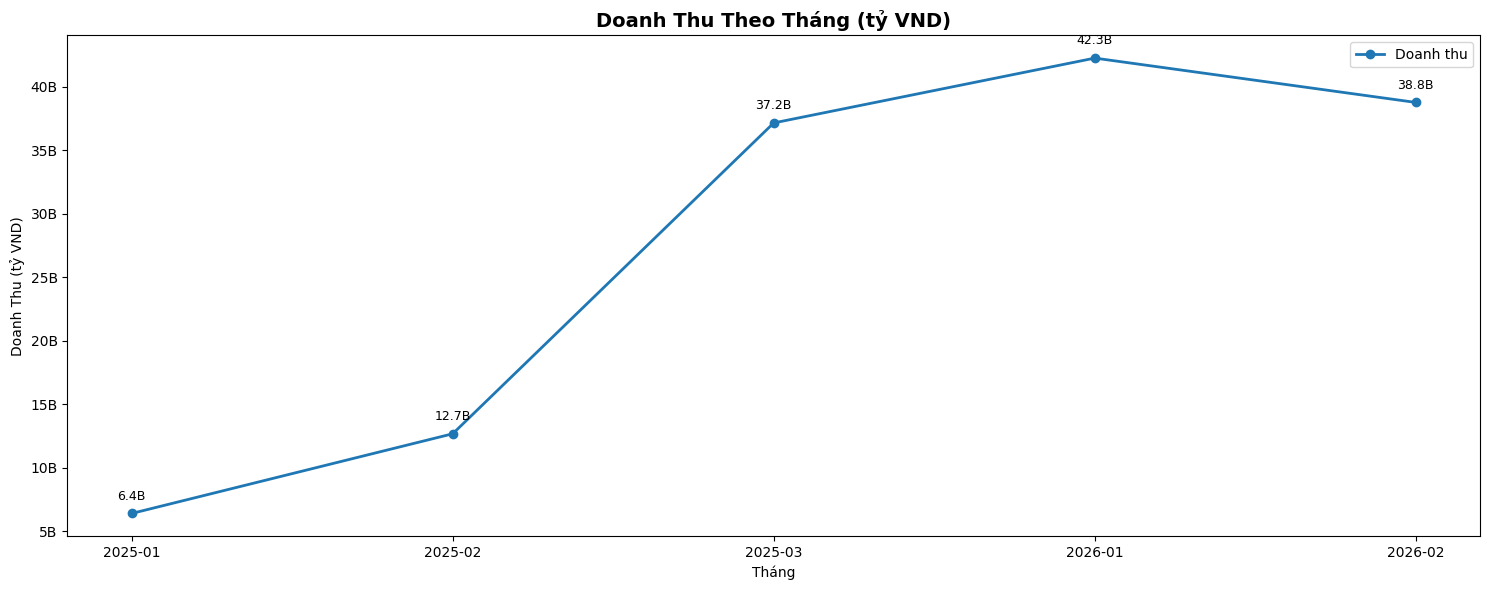

In [4]:
# Cell 4: Doanh thu theo tháng — biểu đồ đường
monthly_rev = df.groupby('year_month')['line_total'].sum().reset_index()
monthly_rev['year_month_str'] = monthly_rev['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(monthly_rev['year_month_str'], monthly_rev['line_total'] / 1e9,
        marker='o', linewidth=2, color='C0')
for i, row in monthly_rev.iterrows():
    ax.annotate(f'{row["line_total"]/1e9:.1f}B',
                (row['year_month_str'], row['line_total']/1e9),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.set_title('Doanh Thu Theo Tháng (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh Thu (tỷ VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}B'))
ax.legend(['Doanh thu'])
fig.tight_layout()
plt.show()

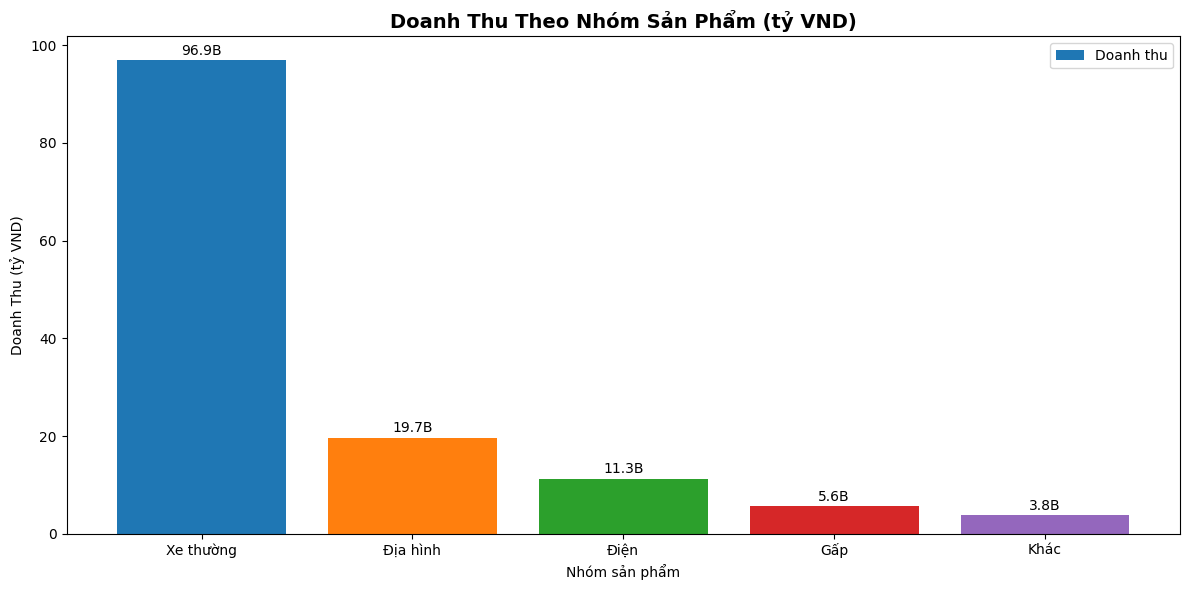

In [5]:
# Cell 5: Doanh thu theo nhóm sản phẩm — biểu đồ cột
group_rev = df.groupby('group_name')['line_total'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [f'C{i}' for i in range(len(group_rev))]
bars = ax.bar(group_rev.index, group_rev.values / 1e9, color=colors)
for bar, val in zip(bars, group_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val/1e9:.1f}B', ha='center', va='bottom', fontsize=10)
ax.set_title('Doanh Thu Theo Nhóm Sản Phẩm (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Nhóm sản phẩm')
ax.set_ylabel('Doanh Thu (tỷ VND)')
ax.legend(['Doanh thu'])
fig.tight_layout()
plt.show()

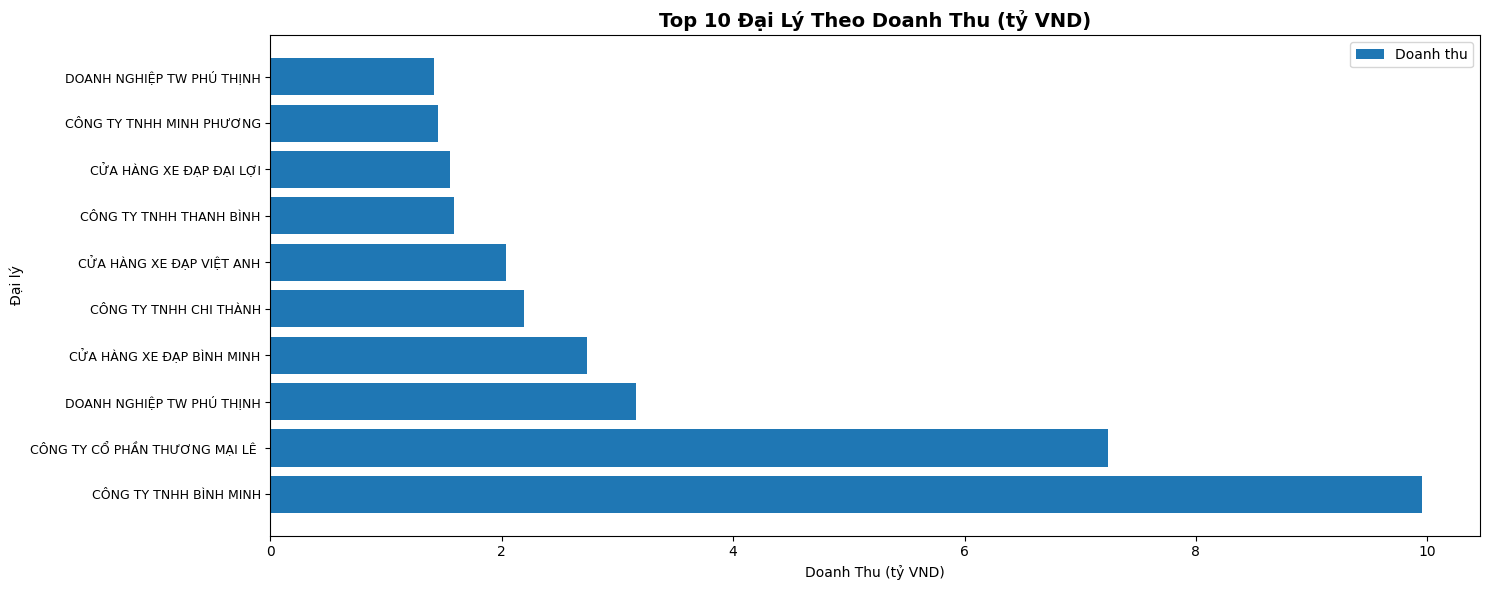

In [6]:
# Cell 6: Top 10 đại lý theo doanh thu
top10_dealers = (df.groupby(['customer_code','customer_name'])['line_total']
                   .sum().sort_values(ascending=False).head(10).reset_index())
top10_dealers['short_name'] = top10_dealers['customer_name'].str[:30]

fig, ax = plt.subplots(figsize=(15, 6))
ax.barh(range(len(top10_dealers)), top10_dealers['line_total'] / 1e9, color='C0')
ax.set_yticks(range(len(top10_dealers)))
ax.set_yticklabels(top10_dealers['short_name'], fontsize=9)
ax.set_title('Top 10 Đại Lý Theo Doanh Thu (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Doanh Thu (tỷ VND)')
ax.set_ylabel('Đại lý')
ax.legend(['Doanh thu'])
fig.tight_layout()
plt.show()

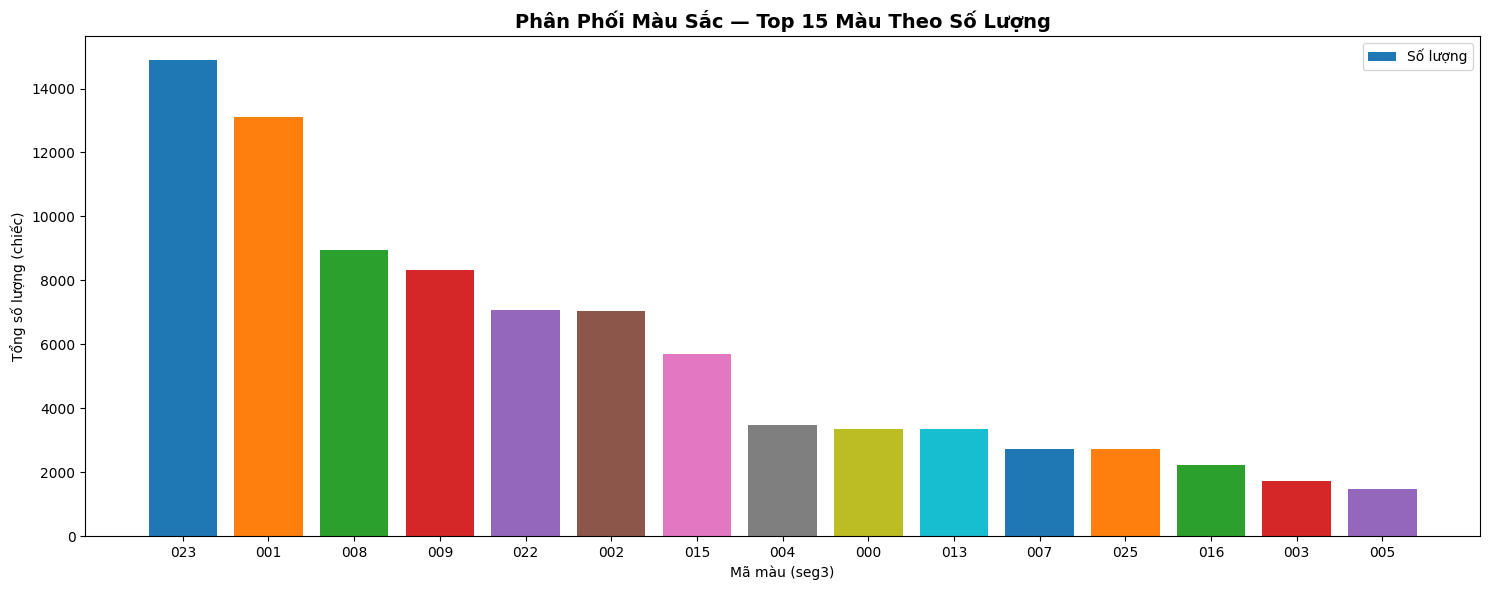

In [7]:
# Cell 7: Phân phối màu sắc theo số lượng
color_qty = df.groupby('seg3_color')['quantity'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(15, 6))
colors_list = [f'C{i%10}' for i in range(len(color_qty))]
ax.bar(color_qty.index, color_qty.values, color=colors_list)
ax.set_title('Phân Phối Màu Sắc — Top 15 Màu Theo Số Lượng', fontsize=14, fontweight='bold')
ax.set_xlabel('Mã màu (seg3)')
ax.set_ylabel('Tổng số lượng (chiếc)')
ax.legend(['Số lượng'])
fig.tight_layout()
plt.show()

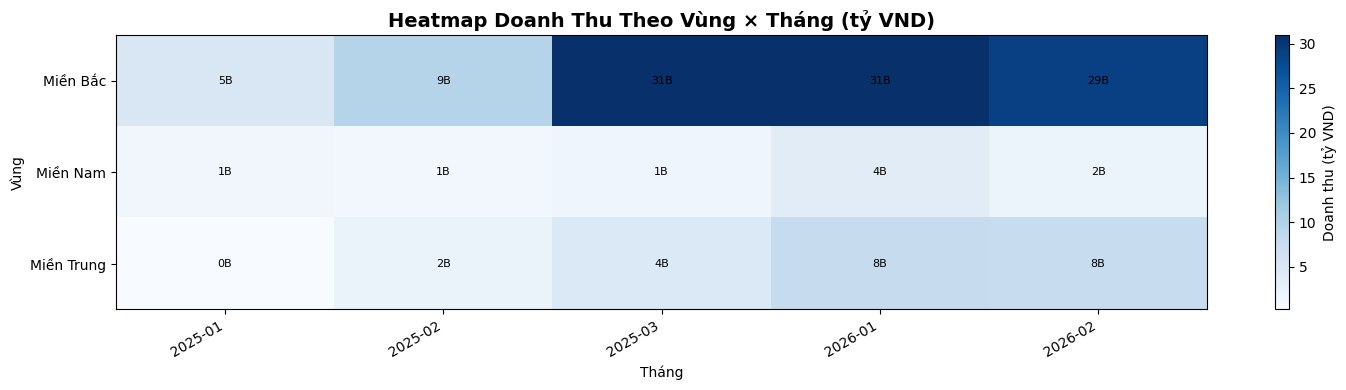

In [8]:
# Cell 8: Heatmap doanh thu vùng × tháng (matplotlib imshow)
region_monthly = (df.dropna(subset=['region'])
                    .groupby(['region','year_month'])['line_total'].sum()
                    .unstack(fill_value=0))
region_monthly.columns = [str(c) for c in region_monthly.columns]
data_matrix = region_monthly.values / 1e9

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(data_matrix, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(region_monthly.columns)))
ax.set_xticklabels(region_monthly.columns, rotation=30, ha='right')
ax.set_yticks(range(len(region_monthly.index)))
ax.set_yticklabels(region_monthly.index)
for i in range(data_matrix.shape[0]):
    for j in range(data_matrix.shape[1]):
        ax.text(j, i, f'{data_matrix[i,j]:.0f}B', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Doanh thu (tỷ VND)')
ax.set_title('Heatmap Doanh Thu Theo Vùng × Tháng (tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Vùng')
fig.tight_layout()
plt.show()

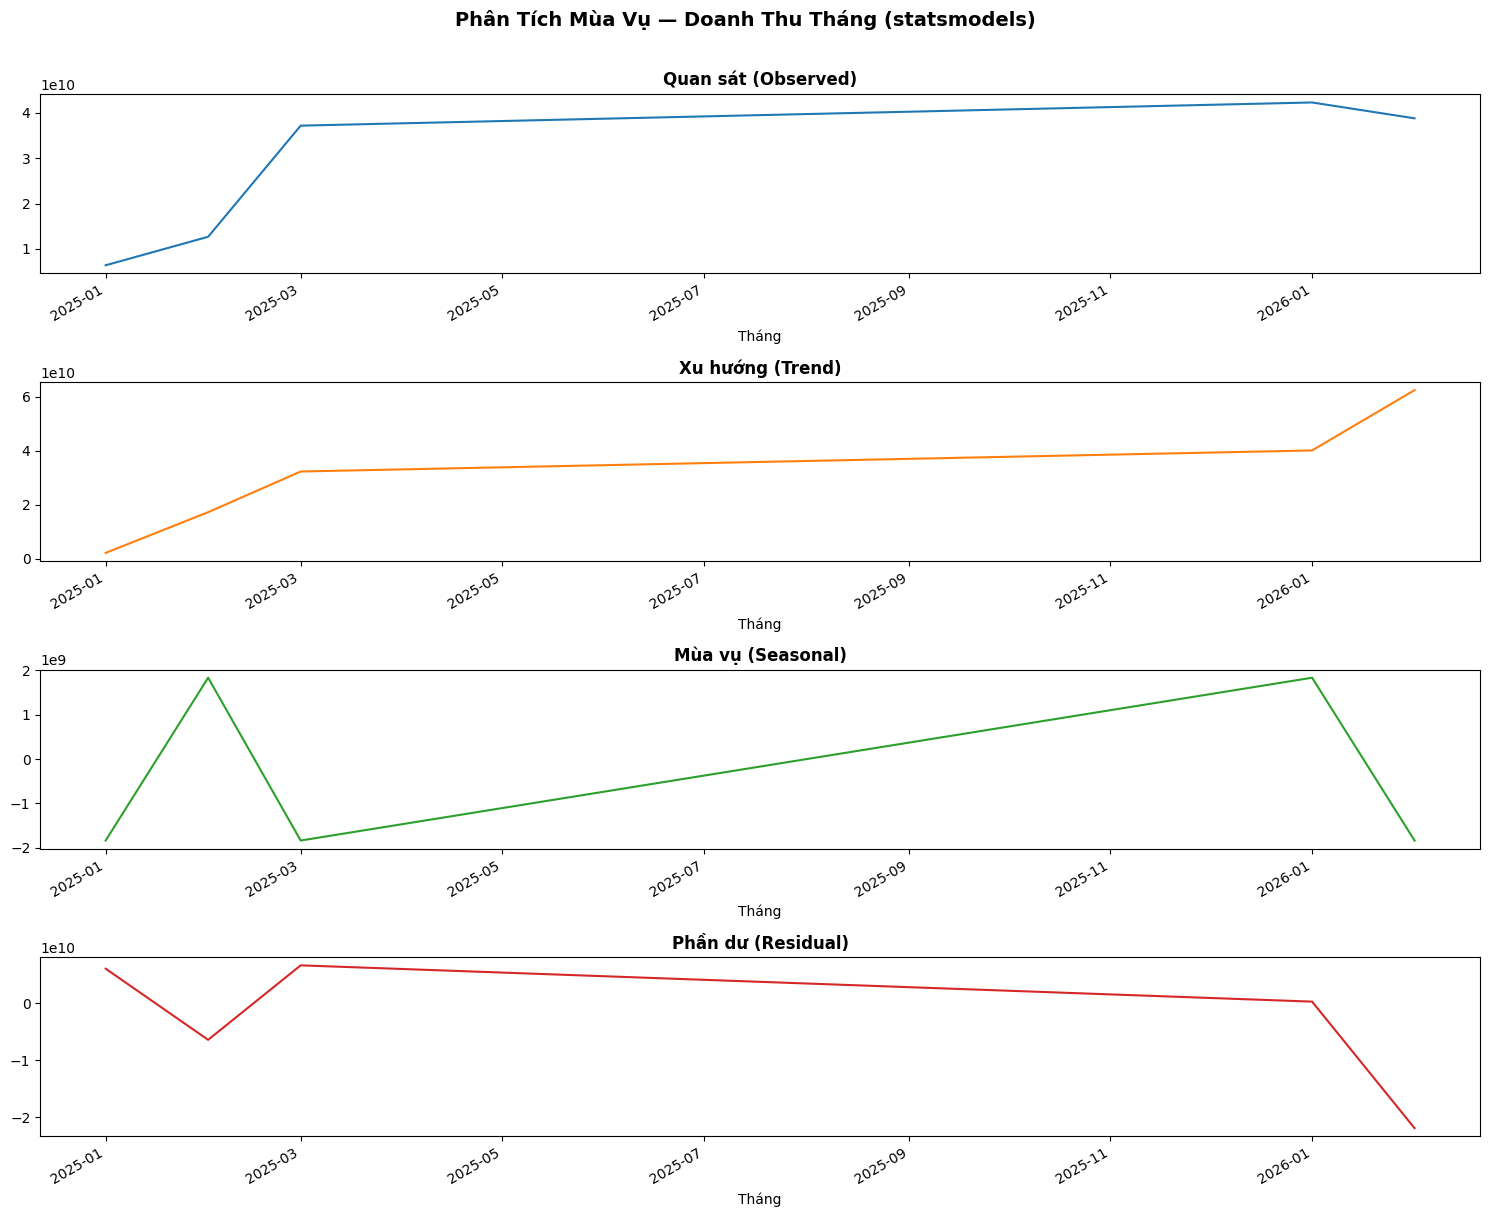

In [9]:
# Cell 9: Phân tích mùa vụ — chuỗi doanh thu tháng tổng hợp
ts_monthly = df.groupby('year_month')['line_total'].sum()
ts_monthly.index = ts_monthly.index.to_timestamp()
ts_monthly = ts_monthly.sort_index()

# Cần ít nhất 2 chu kỳ để phân tách — dùng period=2
try:
    decomp = seasonal_decompose(ts_monthly, model='additive', period=2, extrapolate_trend='freq')
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    decomp.observed.plot(ax=axes[0], color='C0')
    axes[0].set_title('Quan sát (Observed)', fontweight='bold')
    decomp.trend.plot(ax=axes[1], color='C1')
    axes[1].set_title('Xu hướng (Trend)', fontweight='bold')
    decomp.seasonal.plot(ax=axes[2], color='C2')
    axes[2].set_title('Mùa vụ (Seasonal)', fontweight='bold')
    decomp.resid.plot(ax=axes[3], color='C3')
    axes[3].set_title('Phần dư (Residual)', fontweight='bold')
    for a in axes:
        a.set_xlabel('Tháng')
    fig.suptitle('Phân Tích Mùa Vụ — Doanh Thu Tháng (statsmodels)', fontsize=14, fontweight='bold', y=1.01)
    fig.tight_layout()
    plt.show()
except Exception as e:
    print(f'Seasonal decompose lỗi: {e}')

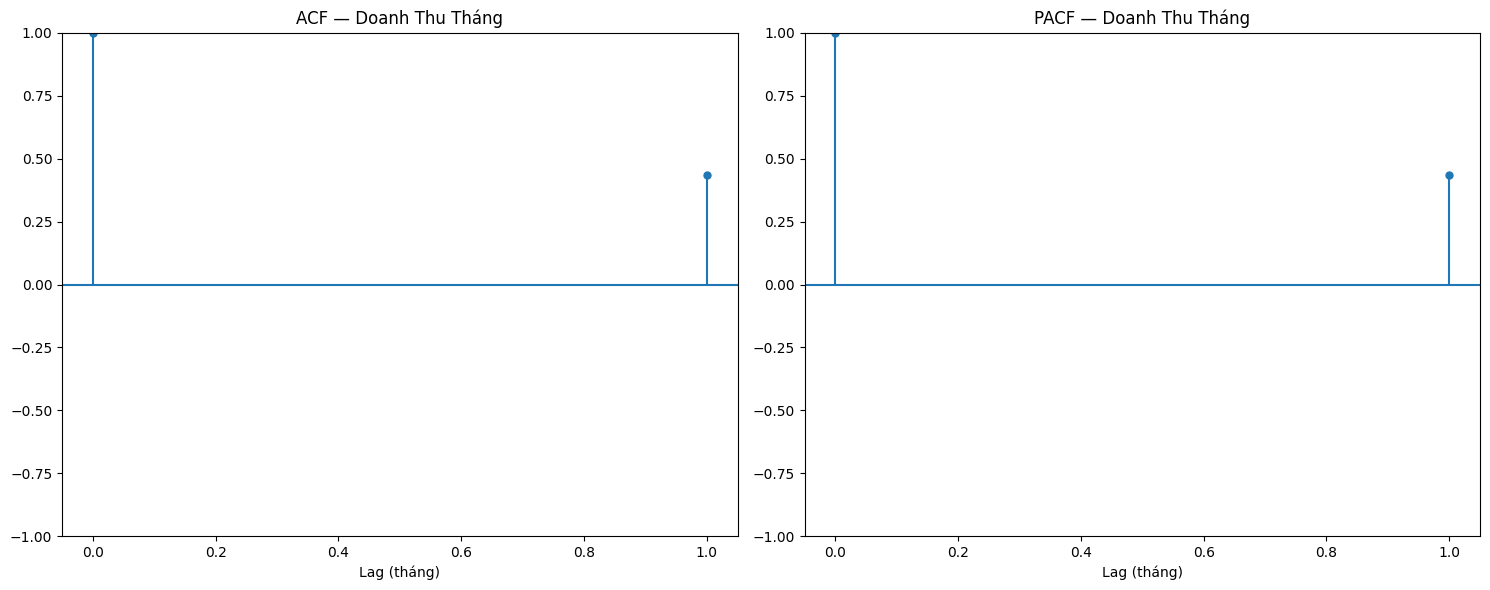

n=5 tháng → max_lags=1. ACF/PACF mang tính tham khảo với data ngắn.


In [10]:
# Cell 10: ACF và PACF — kiểm tra tự tương quan
# 5 điểm dữ liệu → max_lags = n//2 - 1 = 1
n = len(ts_monthly)
max_lags = max(1, n // 2 - 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plot_acf(ts_monthly, lags=max_lags, ax=ax1, title="ACF — Doanh Thu Tháng")
plot_pacf(ts_monthly, lags=max_lags, ax=ax2, title="PACF — Doanh Thu Tháng")
ax1.set_xlabel("Lag (tháng)")
ax2.set_xlabel("Lag (tháng)")
fig.tight_layout()
plt.show()
print(f"n={n} tháng → max_lags={max_lags}. ACF/PACF mang tính tham khảo với data ngắn.")

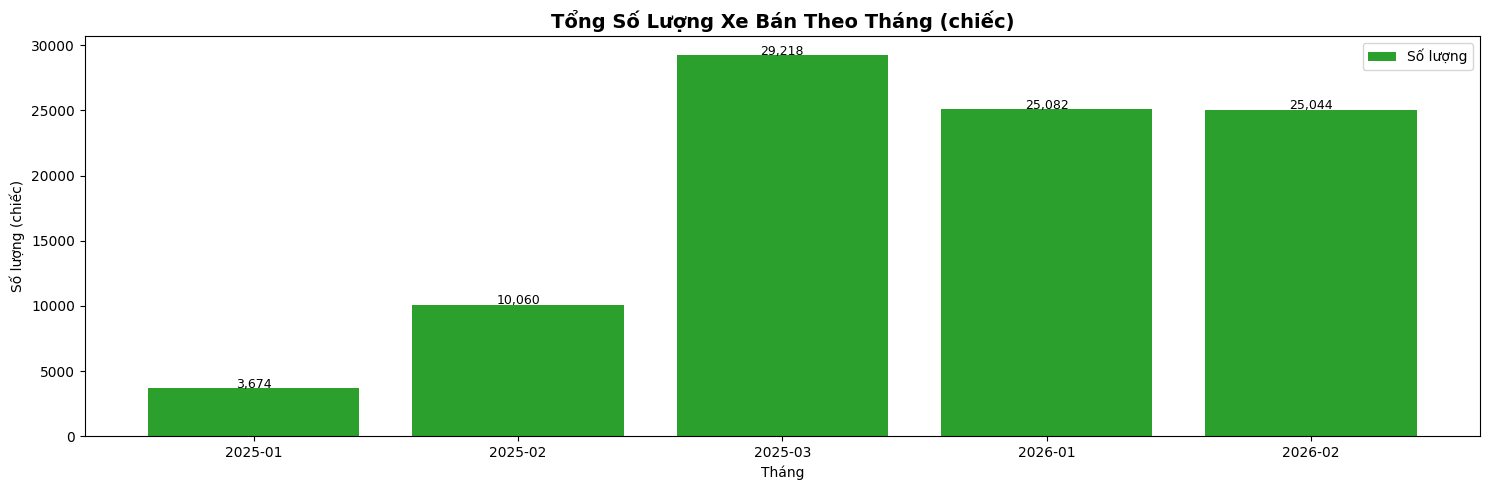

In [11]:
# Cell 11: Phân phối số lượng đơn hàng theo tháng
monthly_qty = df.groupby('year_month')['quantity'].sum().reset_index()
monthly_qty['year_month_str'] = monthly_qty['year_month'].astype(str)

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(monthly_qty['year_month_str'], monthly_qty['quantity'], color='C2')
for _, row in monthly_qty.iterrows():
    ax.text(row['year_month_str'], row['quantity'] + 50, f"{row['quantity']:,.0f}",
            ha='center', fontsize=9)
ax.set_title('Tổng Số Lượng Xe Bán Theo Tháng (chiếc)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Số lượng (chiếc)')
ax.legend(['Số lượng'])
fig.tight_layout()
plt.show()

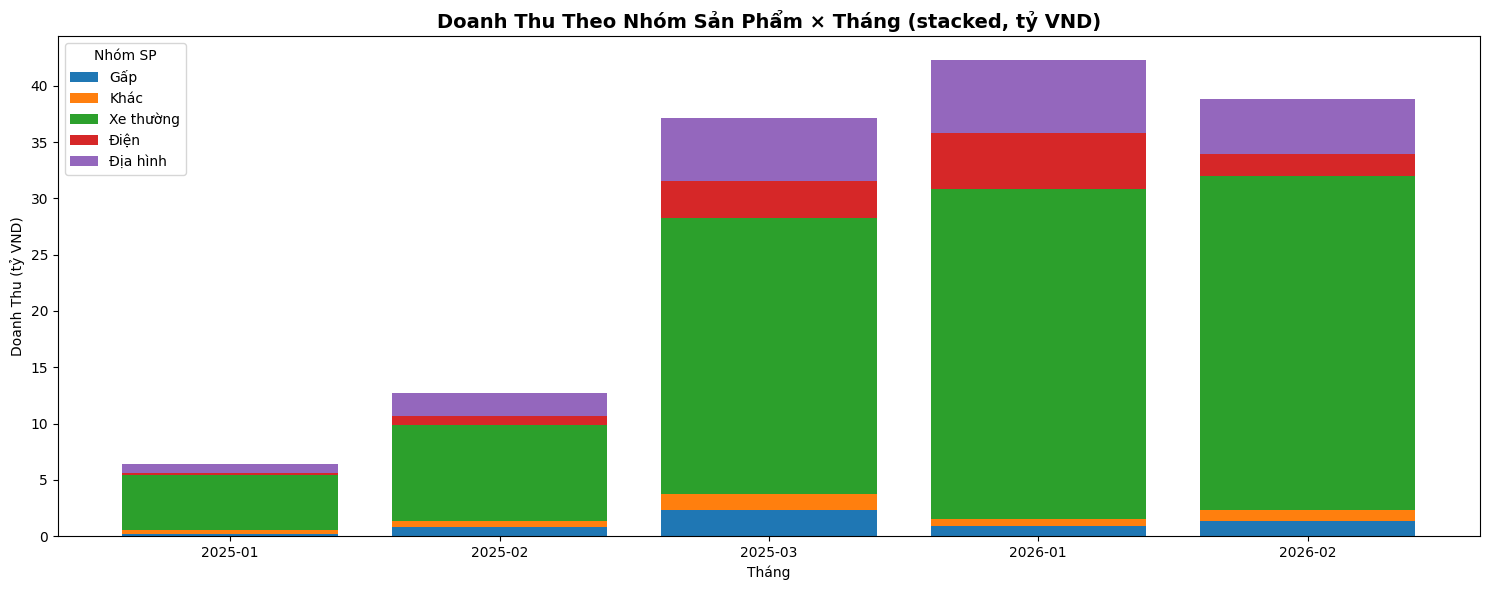

In [12]:
# Cell 12: Doanh thu theo nhóm sản phẩm × tháng (stacked bar)
group_monthly = (df.groupby(['year_month','group_name'])['line_total']
                   .sum().unstack(fill_value=0))
group_monthly.index = [str(i) for i in group_monthly.index]
group_monthly = group_monthly / 1e9

fig, ax = plt.subplots(figsize=(15, 6))
bottom = np.zeros(len(group_monthly))
for i, col in enumerate(group_monthly.columns):
    ax.bar(group_monthly.index, group_monthly[col], bottom=bottom, label=col, color=f'C{i}')
    bottom += group_monthly[col].values
ax.set_title('Doanh Thu Theo Nhóm Sản Phẩm × Tháng (stacked, tỷ VND)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh Thu (tỷ VND)')
ax.legend(title='Nhóm SP')
fig.tight_layout()
plt.show()

## Tổng Kết EDA

**Kết quả chính:**

- **Doanh thu tăng mạnh**: Từ ~6.4 tỷ (2025-01) lên đỉnh ~37.2 tỷ (2025-03), sau đó ổn định ~38-42 tỷ trong Q1/2026
- **Xe thường chiếm ưu thế**: Nhóm 002 (Xe thường) đóng góp >70% doanh thu toàn bộ danh mục
- **Tính mùa vụ rõ ràng**: Tháng 3 có doanh thu vượt trội, có thể do mùa xuân / Tết kết thúc
- **703 đại lý hoạt động**: Phân bố không đều — top 10 đại lý chiếm tỷ lệ lớn doanh thu
- **248 SKU**: Số lượng SKU vừa đủ để phân tích theo nhóm màu
- **ACF/PACF**: Lag-1 có tự tương quan cao → mô hình AR(1) hoặc LightGBM với lag features phù hợp

**Lưu ý:**
- Dữ liệu 2026-03 đã bị loại (đây là rows từ email, không phải đơn hàng thực)
- Seg2='00U' đã bị loại (mã không hợp lệ)
- Thiếu thông tin vùng cho một số đơn hàng → cần xử lý khi phân tích theo vùng